# Básicos de filtrado
## Índice
1. [Introducción a los Filtros](#1-filtros)

2. [Tipos de Filtros](#2-tipos)

3. [Filtros Causales vs Acausales](#3-causal_vs_acausal)

4. [Rangos de Frecuencia - Filtro Pasa-Banda](#4-rangos)


In [1]:
# Celda 0 - Preparación: cargar paquetes y configuraciones
%matplotlib inline
from obspy import *
from obspy.clients.fdsn import Client
import numpy as np
import matplotlib.pylab as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 15, 4
plt.rcParams['lines.linewidth'] = 0.5

## 1. Introducción a los Filtros en Sismología <a id="1-filtros"></a>

Los filtros son sistemas que modifican señales, ya sea como dispositivos físicos o algoritmos matemáticos. 

En sismología tienen tres funciones principales:

- Modificación de señales: Transforman las señales de entrada en versiones modificadas según parámetros específicos

- Corrección instrumental: Compensan las distorsiones propias de los equipos de medición

- Procesamiento de datos: Permiten aislar componentes específicos de las señales sísmicas

### Clasificación básica:

- Por linealidad: Lineales (preferidos) vs No-lineales

- Por implementación: Analógicos (circuitos electrónicos) vs Digitales (algoritmos computacionales)

- Por dominio temporal: Continuos (señales analógicas) vs Discretos (digitales)

### Función de Respuesta en Frecuencia

La función de transferencia del filtro se define como:

$$ T(j\omega) = \frac{Y(j\omega)}{X(j\omega)} $$

Esta relación describe cómo el filtro modifica cada componente frecuencial de la señal.

Para el caso específico de un **filtro pasa-bajos**, la magnitud de la respuesta en frecuencia está dada por:

$$ |T(j\omega)| = \frac{1}{\sqrt{1 + \left(\frac{\omega}{\omega_n}\right)^{2n}}} $$

**Parámetros clave**:

- $\omega$: Frecuencia angular de la señal 
- $\omega_n$: Frecuencia de corte del filtro 
- $n$: Orden del filtro (controla lo abrupto del corte)

> **Nota**: El orden del filtro (n) controla lo abrupto de la transición entre la banda pasante y la banda atenuada. Valores más altos de n producen cortes más pronunciados.

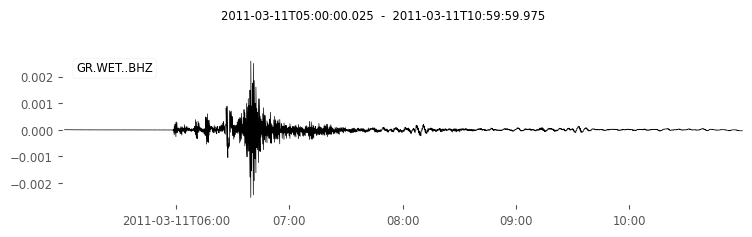

In [3]:
#Preparar datos del terremoto de Tohoku
client = Client("BGR")
t1 = UTCDateTime("2011-03-11T05:00:00.000")
st = client.get_waveforms("GR", "WET", "", "BHZ", t1, t1 + 6 * 60 * 60, 
                         attach_response=True)
st.remove_response(output="VEL")
st.detrend('linear')
st.detrend('demean')
st.plot();

## Tipos de Filtros <a id="2-tipos"></a>
Existen 4 tipos fundamentales de filtros, cada uno con un comportamiento distinto frente a las frecuencias:

- **Filtro Pasa-Bajos**  
   - Unica frecuencia de corte (ω_c)  
   - Permite el paso de frecuencias **por debajo** de ω_c  
   - Atenúa progresivamente frecuencias superiores  

- **Filtro Pasa-Altos**  
   - Unica frecuencia de corte (ω_c)  
   - Permite el paso de frecuencias **por encima** de ω_c  
   - Atenúa progresivamente frecuencias inferiores  

- **Filtro Pasa-Banda**  
   - Dos frecuencias características (ω_min y ω_max)  
   - Permite el paso de frecuencias **dentro del rango** [ω_min, ω_max]  
   - Atenúa frecuencias fuera de esta banda  

- **Filtro Rechaza-Banda**  
   - Dos frecuencias características (ω_min y ω_max)  
   - Bloquea frecuencias **dentro del rango** [ω_min, ω_max]  
   - Permite el paso de frecuencias fuera de esta banda 

In [7]:
# Demostración de tipos de filtros
npts = st[0].stats.npts
dt = st[0].stats.delta
fNy = 1. / (2. * dt)
time = np.arange(0, npts) * dt
freq = np.linspace(0, fNy, npts // 2 + 1)
corners = 4  # orden del filtro

# Frecuencias para los filtros
f0 = 0.04
fmin1 = 0.04
fmax1 = 0.07
fmin2 = 0.03
fmax2 = 0.07

# Funciones de los filtros
LP = 1 / (1 + (freq / f0) ** (2 * corners))  # Pasa-bajos
HP = 1 - LP  # Pasa-altos
wc = fmax1 - fmin1
wb = 0.5 * wc + fmin1
BP = 1/(1 + ((freq - wb)/wc) ** (2 * corners))  # Pasa-banda
wc = fmax2 - fmin2
wb = 0.5 * wc + fmin2
BS = 1 - (1/(1 + ((freq - wb)/wc) ** (2 * corners)))  # Rechaza-banda

# Aplicar filtros
stHP = st.copy().filter('highpass', freq=f0, corners=corners, zerophase=True)
stLP = st.copy().filter('lowpass', freq=f0, corners=corners, zerophase=True)
stBP = st.copy().filter('bandpass', freqmin=fmin1, freqmax=fmax1, corners=corners, zerophase=True)
stBS = st.copy().filter('bandstop', freqmin=fmin2, freqmax=fmax2, corners=corners, zerophase=True)

# filtered traces
stHP = st.copy()
stHP.filter('highpass', freq=f0, corners=corners, zerophase=True)
stLP = st.copy()
stLP.filter('lowpass', freq=f0, corners=corners, zerophase=True)
stBP = st.copy()
stBP.filter('bandpass', freqmin=fmin1, freqmax=fmax1, corners=corners, zerophase=True)
stBS = st.copy()
stBS.filter('bandstop', freqmin=fmin2, freqmax=fmax2, corners=corners, zerophase=True)

# amplitude spectras
Ospec = np.fft.rfft(st[0].data)
LPspec = np.fft.rfft(stLP[0].data)
HPspec = np.fft.rfft(stHP[0].data)
BPspec = np.fft.rfft(stBP[0].data)
BSspec = np.fft.rfft(stBS[0].data)

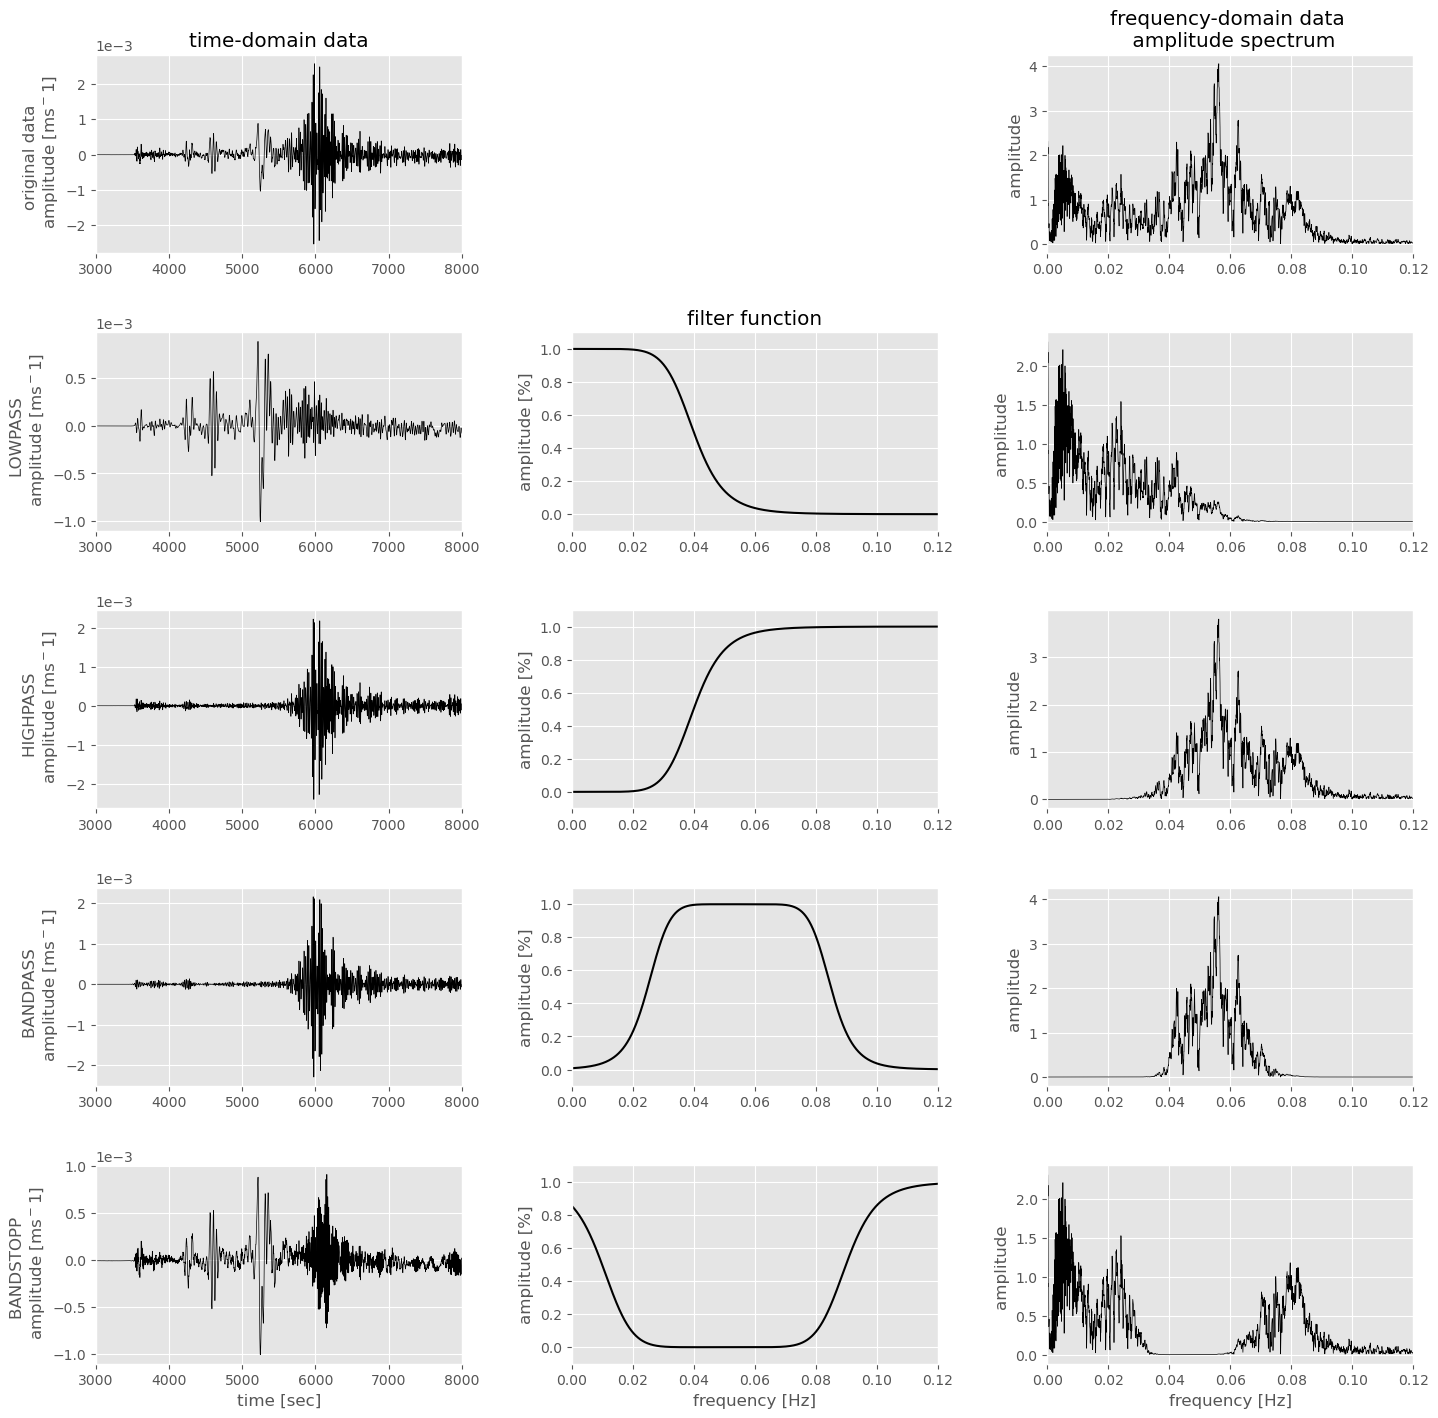

In [8]:
# plot
plt.rcParams['figure.figsize'] = 17, 17
tx1 = 3000
tx2 = 8000
fx2 = 0.12

fig = plt.figure();

ax1 = fig.add_subplot(5,3,1)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(time, st[0].data, 'k')
plt.xlim(tx1, tx2)
plt.title('time-domain data')
plt.ylabel('original data \n amplitude [ms$^-1$]')

ax3 = fig.add_subplot(5,3,3)
plt.plot(freq, abs(Ospec), 'k')
plt.title('frequency-domain data \n amplitude spectrum')
plt.ylabel('amplitude')
plt.xlim(0,fx2)

ax4 = fig.add_subplot(5,3,4)
ax4.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(time, stLP[0].data, 'k')
plt.xlim(tx1, tx2)
plt.ylabel('LOWPASS  \n amplitude [ms$^-1$]')

ax5 = fig.add_subplot(5,3,5)
plt.plot(freq, LP, 'k', linewidth=1.5)
plt.xlim(0,fx2)
plt.ylim(-0.1,1.1)
plt.title('filter function')
plt.ylabel('amplitude [%]')

ax6 = fig.add_subplot(5,3,6)
plt.plot(freq, abs(LPspec), 'k')
plt.ylabel('amplitude ')
plt.xlim(0,fx2)

ax7 = fig.add_subplot(5,3,7)
ax7.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(time, stHP[0].data, 'k')
plt.xlim(tx1, tx2)
plt.ylabel('HIGHPASS  \n amplitude [ms$^-1$]')

ax8 = fig.add_subplot(5,3,8)
plt.plot(freq, HP, 'k', linewidth=1.5)
plt.xlim(0,fx2)
plt.ylim(-0.1,1.1)
plt.ylabel('amplitude [%]')

ax9 = fig.add_subplot(5,3,9)
plt.plot(freq, abs(HPspec), 'k')
plt.ylabel('amplitude ')
plt.xlim(0,fx2)

ax10 = fig.add_subplot(5,3,10)
ax10.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(time, stBP[0].data, 'k')
plt.xlim(tx1, tx2)
plt.ylabel('BANDPASS  \n amplitude [ms$^-1$]')

ax11 = fig.add_subplot(5,3,11)
plt.plot(freq, BP, 'k', linewidth=1.5)
plt.xlim(0,fx2)
plt.ylim(-0.1,1.1)
plt.ylabel('amplitude [%]')

ax12 = fig.add_subplot(5,3,12)
plt.plot(freq, abs(BPspec), 'k')
plt.ylabel('amplitude ')
plt.xlim(0,fx2)

ax13 = fig.add_subplot(5,3,13)
ax13.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(time, stBS[0].data, 'k')
plt.xlim(tx1, tx2)
plt.xlabel('time [sec]')
plt.ylabel('BANDSTOPP \n amplitude [ms$^-1$]')

ax14 = fig.add_subplot(5,3,14)
plt.plot(freq, BS, 'k', linewidth=1.5)
plt.xlim(0,fx2)
plt.ylim(-0.1,1.1)
plt.ylabel('amplitude [%]')
plt.xlabel('frequency [Hz]')

ax15 = fig.add_subplot(5,3,15)
plt.plot(freq, abs(BSspec), 'k')
plt.xlabel('frequency [Hz]')
plt.ylabel('amplitude ')
plt.xlim(0,fx2)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

## Filtros Causales vs Acausales <a id="3-causal_vs_acausal"></a>
**Causal**: La salida depende sólo de entradas pasadas/presentes

**Acausal**: La salida depende de entradas futuras (simétrico)

In [13]:
# Comparación de efectos de filtrado
stf = read()  # Datos de ejemplo de ObsPy
tr = stf[0].detrend('demean').detrend('linear').filter("highpass", freq=2)
print(tr)
t = tr.times()
f = 15.0
ncorners = 4
start = 4                      # tiempo inicial para graficar en segundos (valor inicial: 4)
end = 8                        # tiempo final para graficar en segundos (valor inicial: 8)
amp = 1500                     # rango de amplitud para graficar (valor inicial: 1500)

# Diferentes configuraciones de filtros
tr_filt = tr.copy().filter('lowpass', freq=f, zerophase=True, corners=2)
tr_filt2 = tr.copy().filter('lowpass', freq=f, zerophase=True, corners=ncorners)
tr_filt3 = tr.copy().filter('lowpass', freq=f, zerophase=False, corners=ncorners)

BW.RJOB..EHZ | 2009-08-24T00:20:03.000000Z - 2009-08-24T00:20:32.990000Z | 100.0 Hz, 3000 samples


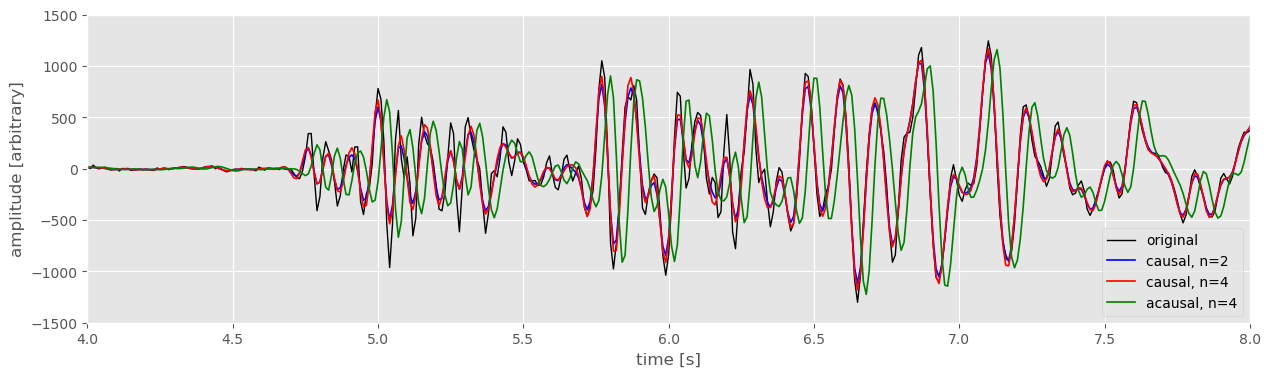

In [14]:
plt.rcParams['figure.figsize'] = 15, 4
plt.plot(t, tr.data, 'k', label='original', linewidth=1.)
plt.plot(t, tr_filt.data, 'b', label='causal, n=2', linewidth=1.2)
plt.plot(t, tr_filt2.data, 'r', label='causal, n=%s' % ncorners, linewidth=1.2)
plt.plot(t, tr_filt3.data, 'g', label='acausal, n=%s' % ncorners, linewidth=1.2)

plt.xlabel('time [s]')
plt.xlim(start, end)    
plt.ylim(-amp, amp)
plt.ylabel('amplitude [arbitrary]')
plt.legend(loc='lower right')

plt.show()

## Rangos de Frecuencia - Filtro Pasa-Banda <a id="4-rangos"></a>

In [16]:
# Obtener datos de evento en Kazajistán
c = Client("IRIS")
tmp1 = UTCDateTime("1989-07-08T03:40:00.0")
tmp2 = UTCDateTime("1989-07-08T04:05:00.0")
dat = c.get_waveforms("CD", "WMQ", "", "BH*", tmp1, tmp2, attach_response=True)
dat.detrend('linear').detrend('demean').remove_response(output="VEL")

3 Trace(s) in Stream:
CD.WMQ..BHE | 1989-07-08T03:48:37.790000Z - 1989-07-08T04:04:41.040000Z | 20.0 Hz, 19266 samples
CD.WMQ..BHN | 1989-07-08T03:48:37.790000Z - 1989-07-08T04:04:41.040000Z | 20.0 Hz, 19266 samples
CD.WMQ..BHZ | 1989-07-08T03:48:37.790000Z - 1989-07-08T04:04:41.040000Z | 20.0 Hz, 19266 samples

In [17]:
# Filtrar en diferentes bandas
chanel = 2
tm = dat[chanel].times()
xmin = 0
xmax = 700

dat1 = dat[chanel].copy()
dat2 = dat[chanel].copy()
dat2.filter(type="bandpass", freqmin=0.01, freqmax=0.05)
dat3 = dat[chanel].copy()
dat3.filter(type="bandpass", freqmin=0.05, freqmax=0.1)
dat4 = dat[chanel].copy()
dat4.filter(type="bandpass", freqmin=0.1, freqmax=0.5)
dat5 = dat[chanel].copy()
dat5.filter(type="bandpass", freqmin=0.5, freqmax=1)
dat6 = dat[chanel].copy()
dat6.filter(type="bandpass", freqmin=1., freqmax=5.)
dat7 = dat[chanel].copy()
dat7.filter(type="bandpass", freqmin=5., freqmax=10.)


C:\Users\Huawei\AppData\Roaming\Python\Python311\site-packages\obspy\signal\filter.py:62: UserWarning: Selected high corner frequency (10.0) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


CD.WMQ..BHZ | 1989-07-08T03:48:37.790000Z - 1989-07-08T04:04:41.040000Z | 20.0 Hz, 19266 samples

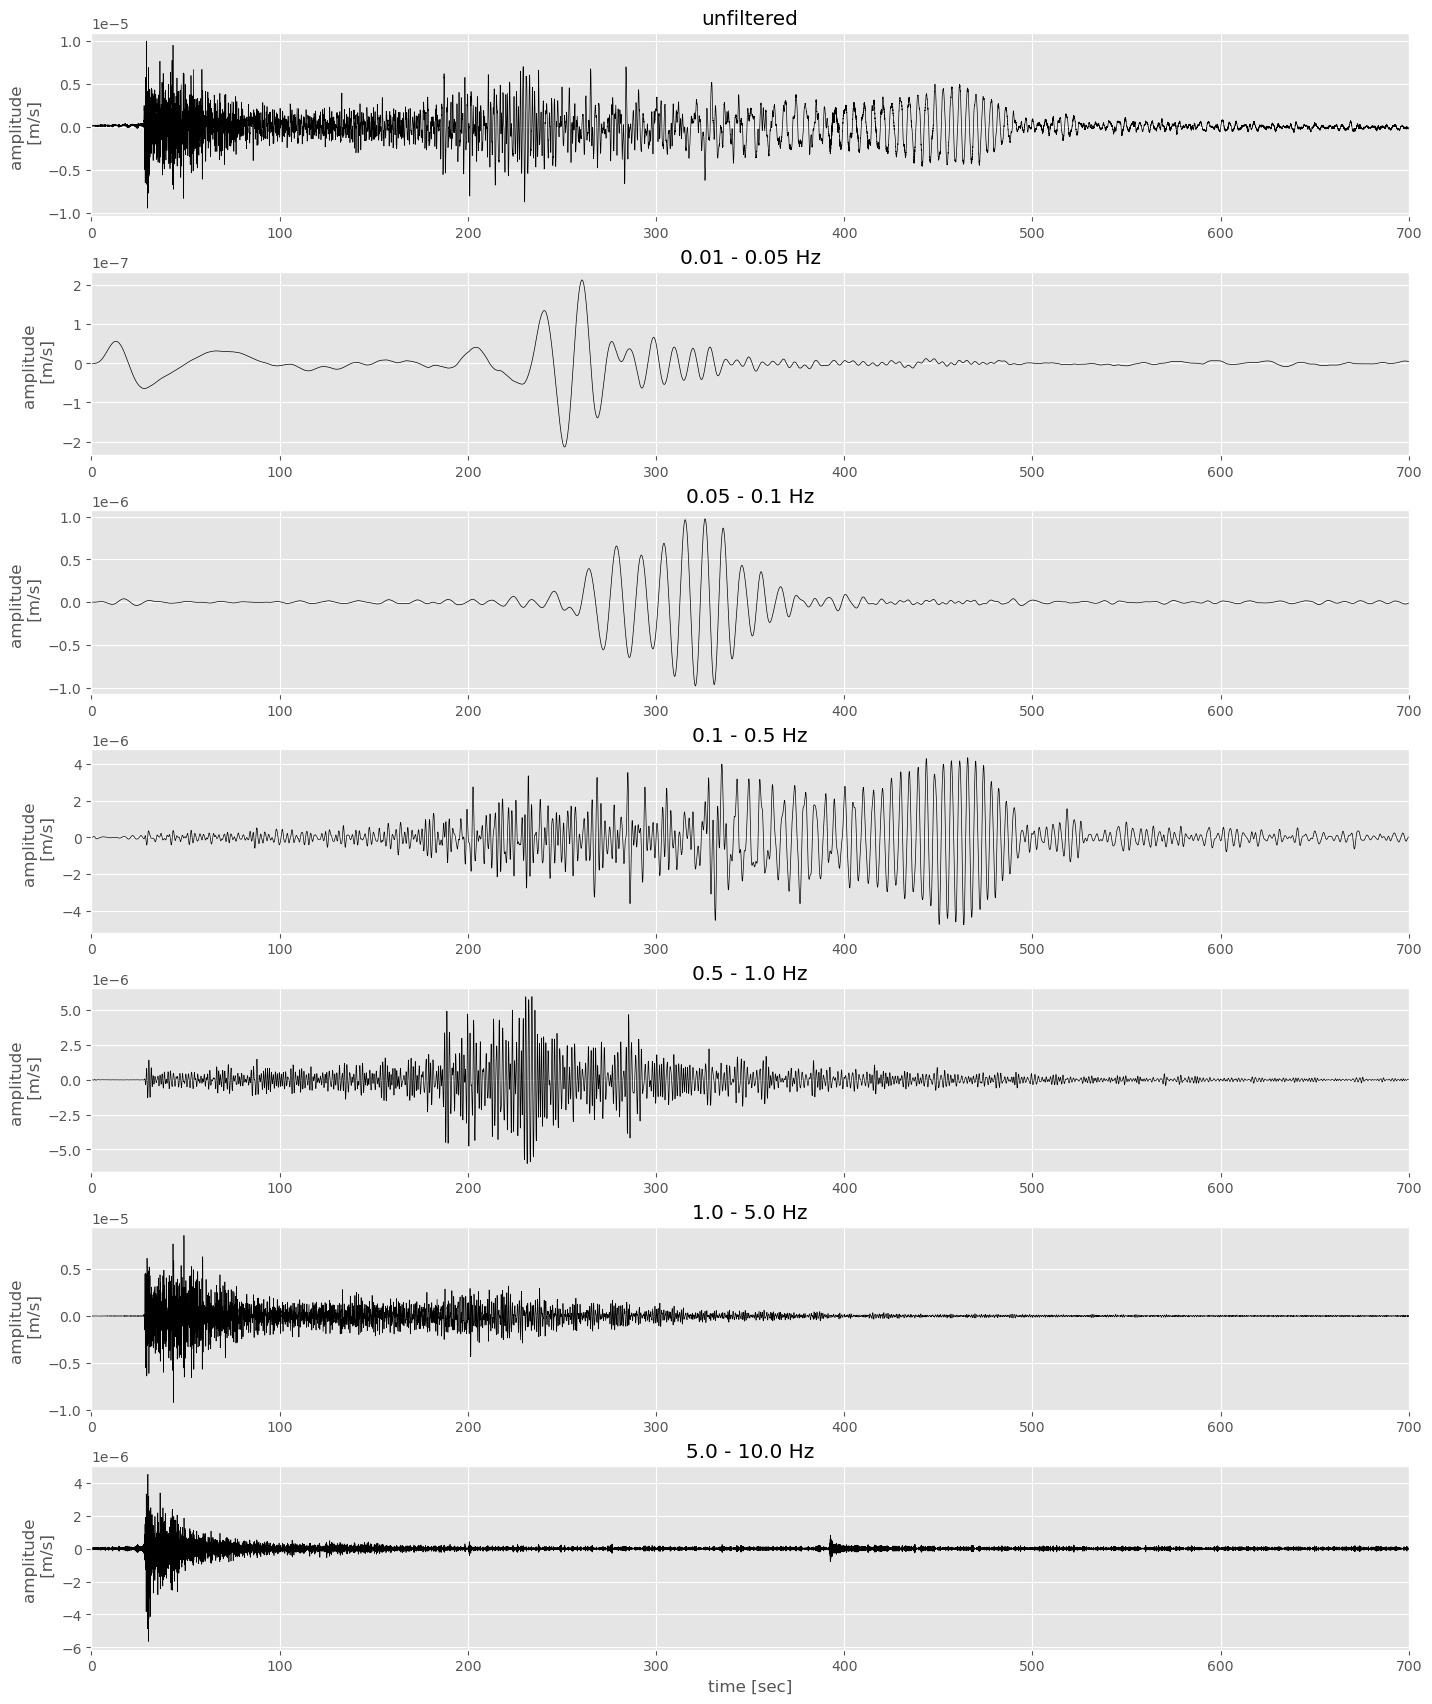

In [18]:
plt.rcParams['figure.figsize'] = 17, 21
fig = plt.figure()
ax1 = fig.add_subplot(7,1,1)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat1.data, 'k')
plt.xlim(xmin, xmax)
plt.title('unfiltered')
plt.ylabel('amplitude \n [m/s]')
ax2 = fig.add_subplot(7,1,2)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat2.data, 'k')
plt.xlim(xmin, xmax)
plt.title('0.01 - 0.05 Hz')
plt.ylabel('amplitude \n [m/s]')
ax3 = fig.add_subplot(7,1,3)
ax3.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat3.data, 'k')
plt.xlim(xmin, xmax)
plt.title('0.05 - 0.1 Hz')
plt.ylabel('amplitude \n [m/s]')
ax4 = fig.add_subplot(7,1,4)
ax4.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat4.data, 'k')
plt.xlim(xmin, xmax)
plt.title('0.1 - 0.5 Hz')
plt.ylabel('amplitude \n [m/s]')
ax5 = fig.add_subplot(7,1,5)
ax5.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat5.data, 'k')
plt.xlim(xmin, xmax)
plt.title('0.5 - 1.0 Hz')
plt.ylabel('amplitude \n [m/s]')
ax6 = fig.add_subplot(7,1,6)
ax6.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat6.data, 'k')
plt.xlim(xmin, xmax)
plt.title('1.0 - 5.0 Hz')
plt.ylabel('amplitude \n [m/s]')
ax7 = fig.add_subplot(7,1,7)
ax7.ticklabel_format(style='sci', axis='y', scilimits=(-1,1))
plt.plot(tm, dat7.data, 'k')
plt.xlim(xmin, xmax)
plt.title('5.0 - 10.0 Hz')
plt.xlabel('time [sec]')
plt.ylabel('amplitude \n [m/s]')
plt.subplots_adjust(hspace=0.3)
plt.show()

**Referencia:** 

Donner, S., Hadziioannou, C. y Nunn, C. (s.f.). Signal Processing: Filtering Basics - Solution. Seismo-Live. https://seismo-live.github.io/html/Signal%20Processing/filter_basics_wrapper.html